In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
H = 300
h = 1e-8
ecf = 0.1
efc = 3
ecc = 3
a = 0.5
b = 1
lam = 4
alpha = 2
delta = 1e-6
kappa = 0.03
Tmax = 78e6+1
T = 1

In [3]:
def LogPrice (xi, ei):
    return ((1-xi)*ei)/xi

def UsTau (xi, ei):
    coef = a*np.abs(LogPrice(xi,ei))
    return np.power(1+coef,alpha)

def Delta_t (xi, ei):
    num = kappa*kappa
    den = h*UsTau(xi,ei)*(1+efc+ecf+H*(1+2*ecc))
    return num/den

def AvanceXi (xi,ei):
    temp = h*Delta_t(xi,ei)*(((1-xi)*ecf*UsTau(xi,ei))-(xi*efc))
    ale = np.sqrt((1-xi)*2*h*xi*Delta_t(xi,ei)*UsTau(xi,ei))*np.random.normal(0, 1)
    return xi+temp+ale

def AvanceEi (xi,ei):
    temp = 2*H*h*ecc*ei*Delta_t(xi,ei)*UsTau(xi,ei)
    ale = np.sqrt((1-ei*ei)*2*h*H*Delta_t(xi,ei)*UsTau(xi,ei))*np.random.normal(0, 1)
    return ei-temp+ale

def inter(t1, x1, t2, x2, t):
    """Interpola x en el tiempo t entre los puntos (t1, x1) y (t2, x2)."""
    return x1 + (x2 - x1) * (t - t1) / (t2 - t1)

In [4]:
np.random.seed(25)  # Puedes usar cualquier número entero

# Defnir los arreglos
size_min = int(Tmax/60)+1
print(size_min)
r_i = np.zeros(size_min)
time = np.zeros(size_min)

#Inicializar las variables
Xiprev = 0.6
Eiprev = 0.0
time[0] = tprev = 0.0
t_target = np.arange(0, Tmax, 60)
print(len(t_target))
t = 0.0
i = 1

while t < Tmax:
    AvXi = min(max(AvanceXi(Xiprev,Eiprev) , delta) , 1-delta)
    AvEi = min(max(AvanceEi(Xiprev,Eiprev) , -1 + delta) , 1-delta)
    t = t + Delta_t(Xiprev,Eiprev)

    if i>=size_min:
        break

    if t_target[i] > tprev and t_target[i] < t:
        x_i_temp = inter(tprev,Xiprev,t,AvXi,t_target[i])
        e_i_temp = inter(tprev,Eiprev,t,AvEi,t_target[i])
        r_i[i] = b * (1 + a * np.abs(LogPrice(x_i_temp, e_i_temp))) * np.sqrt(T)
        i = i+1
        
    
    tprev = t
    Xiprev = AvXi
    Eiprev = AvEi


#k = np.argmax(Deltas)
#print(np.min(Deltas))
#print(np.max(Deltas))
#print(k)
#print(x_i[k])
#print(len(time))


#plt.scatter(e_i[1:],Deltas)
#plt.show

1300001
1300001


In [5]:
r_target = r_i*np.random.normal(0, 1, len(t_target))

#np.savetxt('simu_gauss9.txt', r_target, fmt='%.20f')  # 3 decimales

print(len(r_target))

1300001


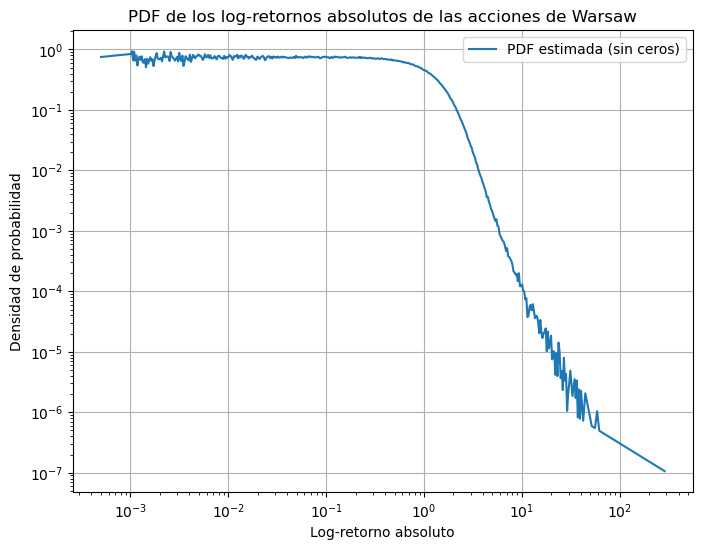

In [8]:
# Convertir a valores absolutos (solo positivos)
data_abs = np.abs(r_target)
data_abs /= np.std(data_abs)

# Definir bins en escala logarítmica con un bin inicial en 0
num_bins = np.insert(np.logspace(np.log10(1e-3), np.log10(max(data_abs)), 500), 0, 0)
#num_bins = np.logspace(np.log10(1e-3), np.log10(max(data_abs)), 500)
# Calcular histograma normalizado (PDF)
hist, bin_edges = np.histogram(data_abs, bins=num_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# **Eliminar valores cero de la PDF y sus correspondientes bins**
nonzero_mask = hist > 0  # Máscara para valores distintos de cero
hist = hist[nonzero_mask]
bin_centers = bin_centers[nonzero_mask]

# Graficar la PDF sin ceros
plt.figure(figsize=(8, 6))
plt.loglog(bin_centers, hist, label='PDF estimada (sin ceros)')
plt.xlabel('Log-retorno absoluto')
plt.ylabel('Densidad de probabilidad')
plt.title('PDF de los log-retornos absolutos de las acciones de Warsaw')
plt.legend()
plt.grid(True)
# Mostrar gráfica
plt.show()

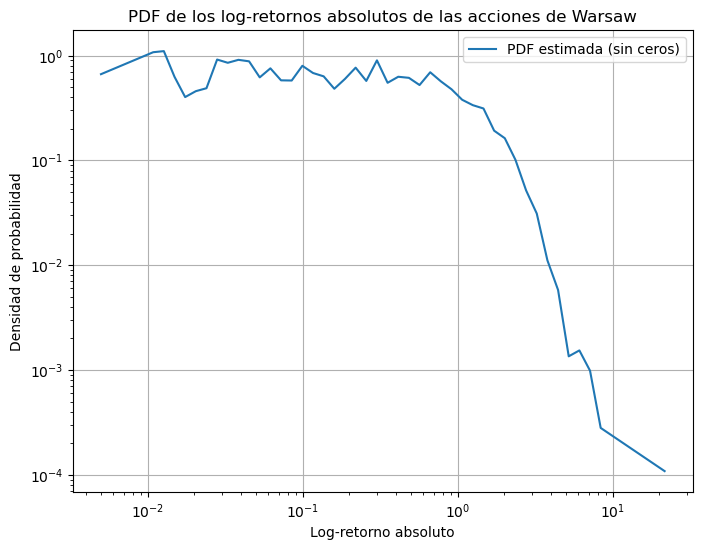

In [17]:
def retornos_diarios(retornos_minuto, minutos_por_dia=480):
    n = len(retornos_minuto)
    n_dias = n // minutos_por_dia  # Número completo de días
    truncado = retornos_minuto[:n_dias * minutos_por_dia]  # Descartamos lo que sobre al final

    # Reshape y suma por fila (cada fila es un día)
    retornos_diarios = truncado.reshape((n_dias, minutos_por_dia)).sum(axis=1)
    
    return retornos_diarios

Diario = retornos_diarios(r_target)

# Convertir a valores absolutos (solo positivos)
data_abs = np.abs(Diario)
data_abs /= np.std(data_abs)

# Definir bins en escala logarítmica con un bin inicial en 0
num_bins = np.insert(np.logspace(np.log10(1e-2), np.log10(max(data_abs)), 50), 0, 0)
#num_bins = np.logspace(np.log10(1e-3), np.log10(max(data_abs)), 100)
# Calcular histograma normalizado (PDF)
hist, bin_edges = np.histogram(data_abs, bins=num_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# **Eliminar valores cero de la PDF y sus correspondientes bins**
nonzero_mask = hist > 0  # Máscara para valores distintos de cero
hist = hist[nonzero_mask]
bin_centers = bin_centers[nonzero_mask]

# Graficar la PDF sin ceros
plt.figure(figsize=(8, 6))
plt.loglog(bin_centers, hist, label='PDF estimada (sin ceros)')
plt.xlabel('Log-retorno absoluto')
plt.ylabel('Densidad de probabilidad')
plt.title('PDF de los log-retornos absolutos de las acciones de Warsaw')
plt.legend()
plt.grid(True)
# Mostrar gráfica
plt.show()

In [18]:
np.savetxt('Noise-dia-lab.txt', Diario, fmt='%.20f')